## FULL ML PIPELINE: EDA| Preprocessing | Modelling| Evaluation| Deployment
## Before you do anything, answer these questions:
- What is the question I am trying to answer?
- Is this a classification or a regression model?(if supervised)
- What is the target variable (column you are trying to predict)
- What are the features the model is to use?(X) (Columns in X)
- How will I measure success? (metrics to use)

## Exploratory data analysis(EDA)
1. Understand the structure and quality of your dataset.
2. Identify missing values, outliers and class imbalance.
3. Visualize distributions and relationships btw features(heatmaps, barchats etc)


## EDA Checklist
1. Load and inspect.
```python
   df.head()
   df.shape
   df.dtypes()
   df.info()
```
- Number of rows/cols, data types, obvious issues.

2. Summary statistics
```python
   df.describe()
```
- Range, Means, Extremes

3. Missing values
```python
   df.isnull().sum()
```
- Which columns have missing data, how much, pattern or random?

4. Check target distribution
```python
   df[target].value_counts()
```
- Shows class imbalance, whether one has a skewed disc etc
- If the target has imbalance > 80/20 it needs special handling

5. Feature distribution
```python
   df.hist() or sns.boxplot()
```
- Normal, Skewed or whether one has outliers

6. Correlations
```python
   df.corr() + heatmap
```
- Highly correlated features

7. Feature Vs Target
- Scatter plots, boxplots per class

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
## Loading data
df = pd.read_csv('Titanic-Dataset.csv')

In [4]:
## Basic inspection
print("Basic inspection results: ")
print(f"Shape: {df.shape}")
print(f"Columns: {list(df.columns)}")

print("First 5 rows: ")
print(df.head())


Basic inspection results: 
Shape: (891, 12)
Columns: ['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']
First 5 rows: 
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  7

In [5]:
print(f"Data types: ")
print(df.dtypes)

Data types: 
PassengerId      int64
Survived         int64
Pclass           int64
Name               str
Sex                str
Age            float64
SibSp            int64
Parch            int64
Ticket             str
Fare           float64
Cabin              str
Embarked           str
dtype: object


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [7]:
## 2. Summary statistics
print("Summary statistics")
print(df.describe().round(2))

Summary statistics
       PassengerId  Survived  Pclass     Age   SibSp   Parch    Fare
count       891.00    891.00  891.00  714.00  891.00  891.00  891.00
mean        446.00      0.38    2.31   29.70    0.52    0.38   32.20
std         257.35      0.49    0.84   14.53    1.10    0.81   49.69
min           1.00      0.00    1.00    0.42    0.00    0.00    0.00
25%         223.50      0.00    2.00   20.12    0.00    0.00    7.91
50%         446.00      0.00    3.00   28.00    0.00    0.00   14.45
75%         668.50      1.00    3.00   38.00    1.00    0.00   31.00
max         891.00      1.00    3.00   80.00    8.00    6.00  512.33


In [8]:
## 3. Missing values
print("Missing values: ")
missing = df.isnull().sum()
missing_pct = df.isnull().mean() * 100

missing_df = pd.DataFrame({
    'count' : missing,
    'percentage' : missing_pct
})

print(missing_df[missing_df['count'] > 0].sort_values('percentage', ascending=False))

Missing values: 
          count  percentage
Cabin       687   77.104377
Age         177   19.865320
Embarked      2    0.224467


In [ ]:
## 4. Target distribution
TARGET = 'Survived'
print("Target distribution")
print(df[TARGET].value_counts())
print(df[TARGET].value_counts(normalize=True).round(3))

## Imbalance > 80/20 needs some handling

Target distribution
Survived
0    549
1    342
Name: count, dtype: int64
Survived
0    0.616
1    0.384
Name: proportion, dtype: float64


Text(0.5, 1.0, 'Age by Target class')

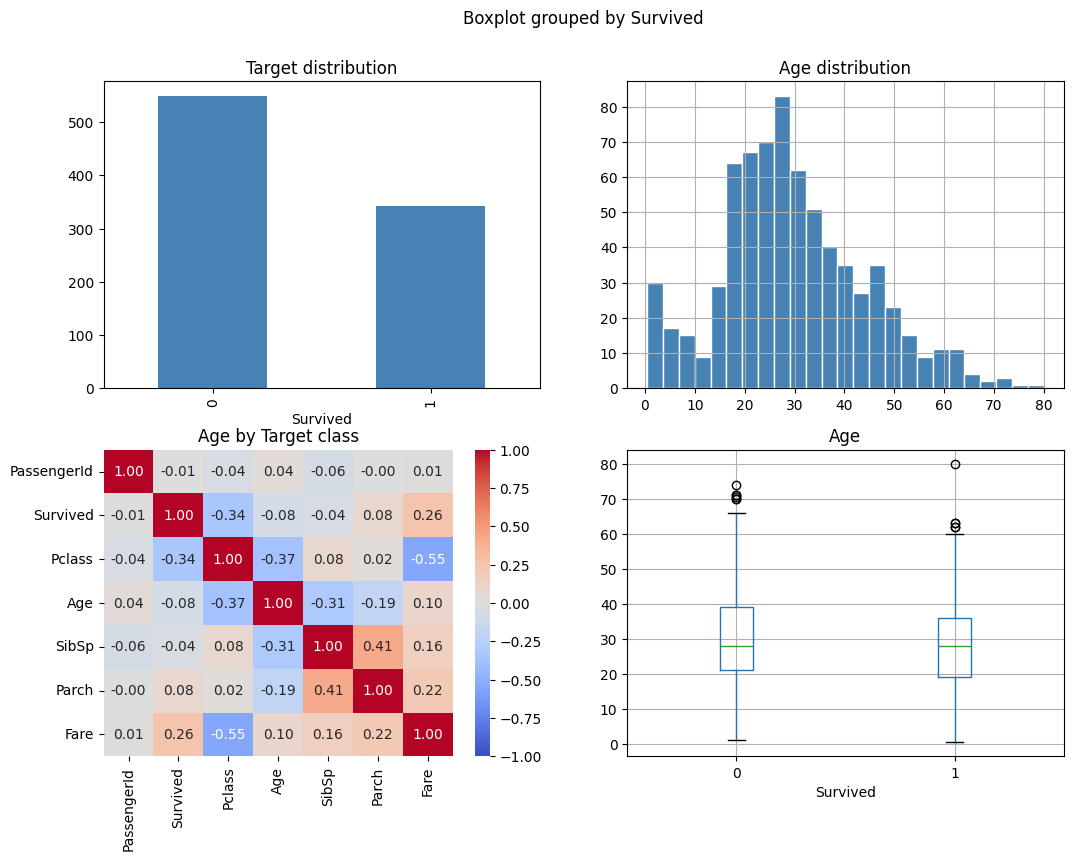

In [12]:
## 5. Visualization
fig, axes = plt.subplots(2, 2, figsize=(12,9))

## Target distribution
df[TARGET].value_counts().plot(kind='bar', ax=axes[0,0], color='steelblue')
axes[0,0].set_title('Target distribution')

## Feature distribution(Age)
df['Age'].dropna().hist(ax=axes[0,1], bins=25, color='steelblue', edgecolor='white')
axes[0,1].set_title('Age distribution')

## Correlation heatmap (numerical columns only)
num_cols = df.select_dtypes(include=np.number).columns
sns.heatmap(df[num_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', ax=axes[1,0],vmin=-1, vmax=1)
axes[1,0].set_title('Correlation Heatmap')

## Feature Vs Target(Age vs Survived)
df.boxplot(column='Age', by=TARGET, ax=axes[1,1])
axes[1,0].set_title('Age by Target class')

## EDA Findings template
1. How many rows and columns?
2. Which columns have missing data and how much?
3. Is the target class balanced or imbalanced?
4. Which features appear mist correlated with the target?
5. Are there any obvious outliers to address?
6. Which columns are you going to DROP and WHY?

## PREPROCESSING PIPELINE
- Handle all missing values with appropriate strategies
- Encode categorical columns correctly
- Build a full ColumnTransformer + Pipeline

## Preprocessing decisions checklist
1. Columns to drop. OPTIOND:IDs, free text, >70% missing, zero variance
2. Numeric imputation. OPTIONS:median(default), mean, constant
3. Categorical impotation. OPTIONS: most_frequent, constant("Unknown")
4. Categorical encoding. OPTIONS: One-hot (<15 categories), Label(ordinal), Target(high cordinality)
5. Numeric scaling. OPTIONS: StandardScaler(default), MinMaxScaler, RobustScaler(outliers)
6. Class imbalance. OPTIONS: None, SMOTE, class_weigh='balanced

In [14]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

In [23]:
## 1. Select and clean pipelines
df_clean = df.copy()

## Drop columns that we are not going to use
cols_to_drop = ['PassengerId', 'Name', 'Cabin', 'Ticket']
df_clean = df_clean.drop(columns=[c for c in cols_to_drop if c in df_clean])

In [24]:
df_clean.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Sex       891 non-null    str    
 3   Age       714 non-null    float64
 4   SibSp     891 non-null    int64  
 5   Parch     891 non-null    int64  
 6   Fare      891 non-null    float64
 7   Embarked  889 non-null    str    
dtypes: float64(2), int64(4), str(2)
memory usage: 55.8 KB


In [25]:
## Separating features from targets
TARGET = 'Survived'
X = df_clean.drop(columns=[TARGET])
y = df_clean[TARGET]

In [26]:
print(f"Features remaining: {list[X.columns]}")
print(f"Shape: {X.shape}")
print(f"The target: {TARGET}")

Features remaining: list[Index(['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked'], dtype='str')]
Shape: (891, 7)
The target: Survived


In [27]:
## Splitting then Preprocessing, Stratify- Ensures that your training and testing sets maintain
#  the same class proportions as the original dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Train: {X_train.shape} Test: {X_test.shape}")

Train: (712, 7) Test: (179, 7)


In [28]:
## Identify column types
num_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = X.select_dtypes(include=['str']).columns.tolist()

print(f"Numerical: {num_cols}")
print(f"Categorical: {cat_cols}")

Numerical: ['Pclass', 'Age', 'SibSp', 'Parch', 'Fare']
Categorical: ['Sex', 'Embarked']


In [31]:
## Building the Pipeline
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', drop='first'))
])

preprocessor = ColumnTransformer([
    ('num', num_pipeline, num_cols),
    ('cat', cat_pipeline, cat_cols)
])

X_tr_transformed = preprocessor.fit_transform(X_train)
print(f"After preprocessing X_trained: {X_tr_transformed.shape}")
print("Ready to add models if no errors")

After preprocessing X_trained: (712, 8)
Ready to add models if no errors


In [32]:
X['Embarked'].unique()

<StringArray>
['S', 'C', 'Q', nan]
Length: 4, dtype: str

## Modelling, Evaluation and Tuning
### Objectives
1. Train at least 2 different models using the preprocessing pipeline.
2. Compare the models using cross-validation and choose the best one
3. Yune the best model with RandomizedSearchCV or Optuna.
4. Produce a final evaluation (eg accuracy, precision, r2 score)

In [33]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier

In [34]:
models = {
    'Logistic Regression' : LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest' : RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting' : GradientBoostingClassifier(random_state=42), 
    'KNN' : KNeighborsClassifier()
}

In [35]:
from sklearn.model_selection import cross_val_score, StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [38]:
## Train in pipeline

results = {}
for name, model in models.items():
    full_pipe= Pipeline([
        ('preprocessor', preprocessor),
        ('model', model)
    ])

    ## Accuracy
    acc_scores = cross_val_score(full_pipe, X_train, y_train, cv=cv, scoring='accuracy')
    f1_scores = cross_val_score(full_pipe, X_train, y_train, cv=cv, scoring='f1') 

## Saving the results
    results[name] = {'acc': acc_scores.mean(), 'f1': f1_scores.mean()}

    print(f"{name} {acc_scores.mean()} {acc_scores.std()} {f1_scores.mean()}")

Logistic Regression 0.7949374569092879 0.02727663790298474 0.7246353792381143
Random Forest 0.794937456909288 0.015098603237695915 0.7288683145600695
Gradient Boosting 0.8258347286516299 0.035418596033379046 0.7587872046093072
KNN 0.7977839062346105 0.021180688430028526 0.721238400224206


In [40]:
results

{'Logistic Regression': {'acc': np.float64(0.7949374569092879),
  'f1': np.float64(0.7246353792381143)},
 'Random Forest': {'acc': np.float64(0.794937456909288),
  'f1': np.float64(0.7288683145600695)},
 'Gradient Boosting': {'acc': np.float64(0.8258347286516299),
  'f1': np.float64(0.7587872046093072)},
 'KNN': {'acc': np.float64(0.7977839062346105),
  'f1': np.float64(0.721238400224206)}}

In [39]:
best_name = max(results, key=lambda k: results[k]['f1'])
print(f"Best model is {best_name}")

Best model is Gradient Boosting


In [41]:
## Tuning the best model- Tuning Random Forest for learning purposes
## Also Random Forest was the most stable.

from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

param_dist = {
    'model_n_estimators' : randint(50, 400),
    'model_max_depth' : randint(2, 25),
    'model_min_samples_split': randint(2, 15),
    'model_min_samples_leaf': randint(1, 8)
}

best_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(random_state=42))
])

search = RandomizedSearchCV(best_pipe, param_distributions=param_dist, n_iter=50, cv=5,
                            scoring='f1', n_jobs=1, random_state=42, verbose=1)
search.fit(X_train, y_train)

print(f"Best cv f1: {search.best_score_:.4f}")
print(f"Best params: {search.best_params_}")

Fitting 5 folds for each of 50 candidates, totalling 250 fits


ValueError: Invalid parameter 'model_max_depth' for estimator Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Pclass', 'Age', 'SibSp',
                                                   'Parch', 'Fare']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore'))]),
                                                  ['Sex', 'Embarked'])])),
                ('model', RandomForestClassifier(random_state=42))]). Valid parameters are: ['memory', 'steps', 'transform_input', 'verbose'].

In [43]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint
 
param_dist = {
'model__n_estimators': randint(50, 400),
'model__max_depth': randint(2, 25),
'model__min_samples_split': randint(2, 15),
'model__min_samples_leaf': randint(1, 8)
}
 
best_pipe = Pipeline([
('preprocessor', preprocessor),
('model', RandomForestClassifier(random_state=42))
])
 
search = RandomizedSearchCV(best_pipe, param_distributions=param_dist, n_iter=50,cv=5, 
                            scoring='f1', n_jobs=-1, random_state=42, verbose=1)
search.fit(X_train, y_train)
 
print(f"Best cv f1: {search.best_score_:.4f}")
print(f"Best params: {search.best_params_}")

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best cv f1: 0.7589
Best params: {'model__max_depth': 22, 'model__min_samples_leaf': 2, 'model__min_samples_split': 5, 'model__n_estimators': 141}


In [ ]:
## Final Evaluation
final_model = search.best_estimator_
final_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

In [46]:
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

y_pred = final_model.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.80      0.89      0.84       110
           1       0.79      0.65      0.71        69

    accuracy                           0.80       179
   macro avg       0.80      0.77      0.78       179
weighted avg       0.80      0.80      0.79       179



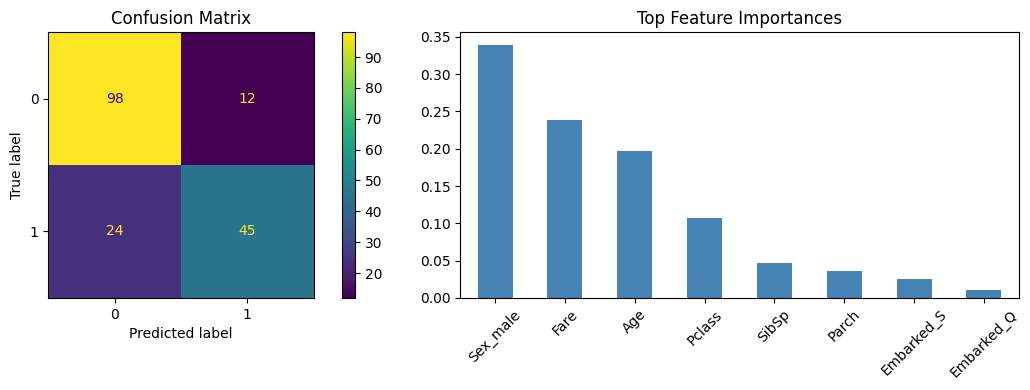

In [49]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize= (12, 4))

## Left plot: Confusion Matrix
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=axes[0])
axes[0].set_title('Confusion Matrix')

## Right plot
if hasattr(final_model['model'], 'feature_importances_'):
    num_names = num_cols
    cat_names = (final_model['preprocessor']
                 .named_transformers_['cat']['encoder']
                 .get_feature_names_out(cat_cols).tolist())
    all_names = num_names + cat_names

    ##2. Map importances to names
    importances = pd.Series(final_model['model'].feature_importances_,
                            index=all_names).sort_values(ascending=False)

    ##3. Plot (bar)
    importances.plot(kind='bar', ax=axes[1], color='steelblue')
    axes[1].set_title('Top Feature Importances')
    axes[1].tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.show()